# Task 6: House Price Prediction

**Objective:** Predict house prices using property features such as size, bedrooms, and location.

This notebook performs preprocessing, trains regression models, evaluates with MAE/RMSE, and visualizes results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Housing.csv')

In [3]:
# Preprocessing
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for c in binary_cols:
    df[c] = (df[c].str.strip().str.lower() == 'yes').astype(int)
 
furn_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
df['furnishingstatus'] = df['furnishingstatus'].str.strip().str.lower().map(furn_map)
 
features = ['area','bedrooms','bathrooms','stories','mainroad','guestroom',
            'basement','hotwaterheating','airconditioning','parking','prefarea','furnishingstatus']
X = df[features]
y = df['price']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [4]:
# Training
lr = LinearRegression().fit(X_train_s, y_train)
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42).fit(X_train_s, y_train)
 
y_pred_lr = lr.predict(X_test_s)
y_pred_gb = gb.predict(X_test_s)

In [5]:
# Metrics
def metrics(yt, yp):
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = 1 - np.sum((yt-yp)**2)/np.sum((yt-yt.mean())**2)
    return mae, rmse, r2
 
mae_lr, rmse_lr, r2_lr = metrics(y_test, y_pred_lr)
mae_gb, rmse_gb, r2_gb = metrics(y_test, y_pred_gb)
 
print(f"Linear Regression  → MAE:{mae_lr:,.0f}  RMSE:{rmse_lr:,.0f}  R²:{r2_lr:.3f}")
print(f"Gradient Boosting  → MAE:{mae_gb:,.0f}  RMSE:{rmse_gb:,.0f}  R²:{r2_gb:.3f}")

Linear Regression  → MAE:979,680  RMSE:1,331,071  R²:0.649
Gradient Boosting  → MAE:974,955  RMSE:1,315,527  R²:0.658


Text(0.5, 1.0, 'Price Distribution')

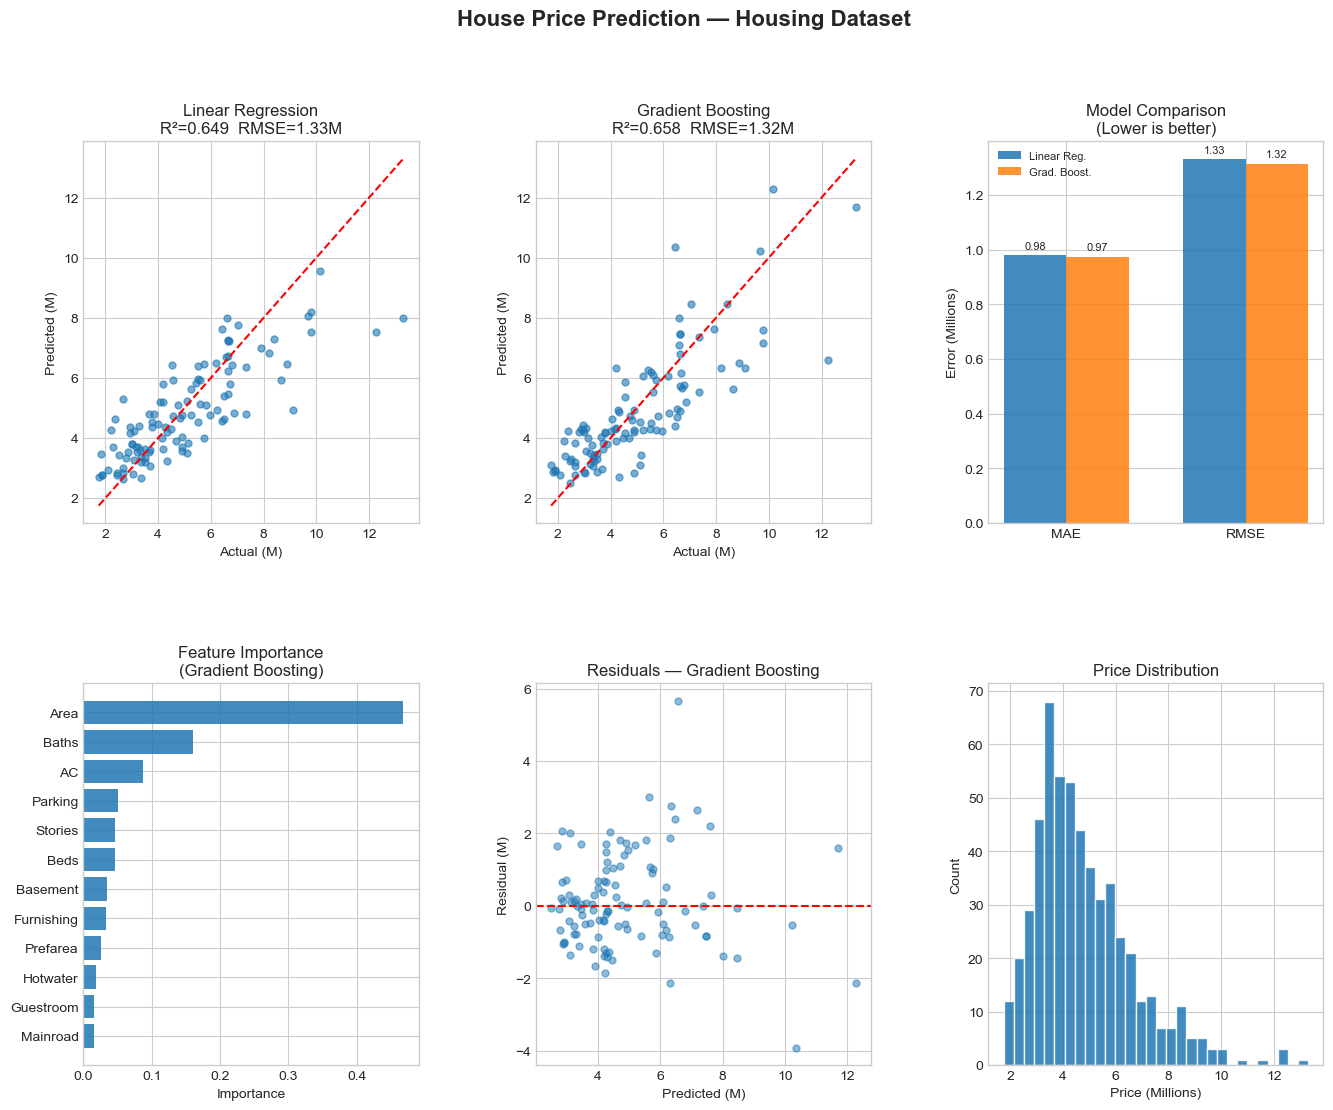

In [16]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('House Price Prediction — Housing Dataset', fontsize=16, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.35)
 
# Panel 1 – Actual vs Predicted LR
ax1 = fig.add_subplot(gs[0,0])
ax1.scatter(y_test/1e6, y_pred_lr/1e6, alpha=0.6, s=25)
mn,mx = min(y_test.min(),y_pred_lr.min())/1e6, max(y_test.max(),y_pred_lr.max())/1e6
ax1.plot([mn,mx],[mn,mx],'r--',lw=1.5)
ax1.set_xlabel('Actual (M)'); ax1.set_ylabel('Predicted (M)')
ax1.set_title(f'Linear Regression\nR²={r2_lr:.3f}  RMSE={rmse_lr/1e6:.2f}M')

# Panel 2 – Actual vs Predicted GB
ax2 = fig.add_subplot(gs[0,1])
ax2.scatter(y_test/1e6, y_pred_gb/1e6, alpha=0.6, s=25)
ax2.plot([mn,mx],[mn,mx],'r--',lw=1.5)
ax2.set_xlabel('Actual (M)'); ax2.set_ylabel('Predicted (M)')
ax2.set_title(f'Gradient Boosting\nR²={r2_gb:.3f}  RMSE={rmse_gb/1e6:.2f}M')

# Panel 3 – Metrics comparison
ax3 = fig.add_subplot(gs[0,2])
labels = ['MAE', 'RMSE']
lr_v = [mae_lr/1e6, rmse_lr/1e6]
gb_v = [mae_gb/1e6, rmse_gb/1e6]
x = np.arange(2); w = 0.35
b1 = ax3.bar(x-w/2, lr_v, w, label='Linear Reg.', alpha=0.85)
b2 = ax3.bar(x+w/2, gb_v, w, label='Grad. Boost.', alpha=0.85)
ax3.bar_label(b1, fmt='%.2f', padding=3, fontsize=8)
ax3.bar_label(b2, fmt='%.2f', padding=3, fontsize=8)
ax3.set_xticks(x); ax3.set_xticklabels(labels)
ax3.set_ylabel('Error (Millions)'); ax3.set_title('Model Comparison\n(Lower is better)')
ax3.legend(fontsize=8)

# Panel 4 – Feature Importance
ax4 = fig.add_subplot(gs[1,0])
imp = gb.feature_importances_
feat_labels = ['Area','Beds','Baths','Stories','Mainroad','Guestroom',
               'Basement','Hotwater','AC','Parking','Prefarea','Furnishing']
idx = np.argsort(imp)
ax4.barh(np.array(feat_labels)[idx], imp[idx], alpha=0.85)
ax4.set_xlabel('Importance'); ax4.set_title('Feature Importance\n(Gradient Boosting)')

# Panel 5 – Residuals GB
ax5 = fig.add_subplot(gs[1,1])
resid = (y_test - y_pred_gb)/1e6
ax5.scatter(y_pred_gb/1e6, resid, alpha=0.5, s=25)
ax5.axhline(0, color='red', lw=1.5, ls='--')
ax5.set_xlabel('Predicted (M)'); ax5.set_ylabel('Residual (M)')
ax5.set_title('Residuals — Gradient Boosting')

# Panel 6 – Price distribution
ax6 = fig.add_subplot(gs[1,2])
ax6.hist(df['price']/1e6, bins=30, edgecolor='white', alpha=0.85)
ax6.set_xlabel('Price (Millions)'); ax6.set_ylabel('Count')
ax6.set_title('Price Distribution')